In [1]:
#imports

import kagglehub
import pandas as pd
import spacy
import os
#from ydata_profiling import ProfileReport
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Data Collection and Dataset Setup

In this section, we download the TED Talks dataset directly from Kaggle using the `kagglehub` package.  
The dataset contains metadata about TED Talks, including speaker information, tags, descriptions, and full transcripts.

The dataset files are automatically cached locally after download, which avoids downloading them repeatedly every time the notebook is executed.

Main files used:
- `ted_main.csv` → contains metadata about each TED Talk
- `transcripts.csv` → contains the full transcripts

In [2]:

# Download latest version
path = kagglehub.dataset_download("rounakbanik/ted-talks")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\elzes\.cache\kagglehub\datasets\rounakbanik\ted-talks\versions\3


# 2. Combining the Dataset Files

The TED dataset is split into two separate CSV files:

1. `ted_main.csv` → metadata and descriptive information
2. `transcripts.csv` → full spoken transcripts

To make analysis easier, both files are merged into a single dataframe using a shared identifier.
After merging, the dataframe becomes the main working dataset used throughout the notebook.


In [3]:
main        = pd.read_csv(os.path.join(path, "ted_main.csv"))
transcripts = pd.read_csv(os.path.join(path, "transcripts.csv"))

df = pd.concat([main, transcripts], axis=1) # join the 2 seperate csv
#df = df.head(5) # get first 50
df = df.drop(columns=["url"]) # drop URL cause it is useless
df = df.dropna(subset=["transcript"]).reset_index(drop=True) # drop all rows that have no transcript

df.to_csv("../data/processed/ted_combined.csv", index=False)
print(f"Shape: {df.shape}  —  saved to ./data/processed/ted_combined.csv")

Shape: (2467, 17)  —  saved to ./data/processed/ted_combined.csv


# 3. Text Preprocessing

Before applying our techniques, the transcript text needs to be cleaned and standardized.

We use **spaCy** for preprocessing because it provides fast tokenization, lemmatization and tagging.

The preprocessing pipeline performs several important steps:

- Remove stopwords
- Tokenize the transcript into individual words
- Lemmatize tokens (reduce words to their root form)

Example:
- `"running"` → `"run"`
- `"children"` → `"child"`

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess(doc):
    tokens = [t.lemma_ for t in doc
              if not t.is_stop and not t.is_space
              and t.is_alpha and len(t.lemma_) > 2]
    return tokens 

texts = df["transcript"].tolist()
df["clean_tokens"] = [preprocess(doc) for doc in nlp.pipe(texts, n_process=6 ,batch_size=64)] # faster than .apply
df["clean_text"]   = df["clean_tokens"].apply(" ".join)
print("done")

done


# 4. Exploratory Data Analysis (EDA)

At this stage, we explore the dataset to better understand its structure and characteristics.
A profiling report can also be generated to quickly summarize the dataset automatically.

In [5]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="TED Talks EDA")
# profile.to_file("report.html")
# profile.to_notebook_iframe()

# 5. NRC Emotion Analysis

The NRC Lexicon is used to detect emotional signals inside the transcripts.
Unlike basic sentiment analysis that only predicts positive or negative tone, NRC identifies multiple emotions such as:

- Joy
- Anger
- Fear
- Trust
- Sadness
- Surprise
- Anticipation

The `NRCLex` library scans the cleaned transcript text and calculates emotion frequencies.
This allows us to study not only whether a TED Talk is positive or negative, but also which emotions are most dominant.


In [6]:
def analyse_nrc(tkns):
    if isinstance(tkns, str): return NRCLex(tkns).affect_frequencies
    text_object = NRCLex()
    text_object.load_token_list(tkns)
    return text_object.affect_frequencies
    
df["nrc_anal"] = df["clean_tokens"].apply(analyse_nrc)


vader analyse

In [7]:
sia = SentimentIntensityAnalyzer()
df["vader_anal"] = df["transcript"].apply(sia.polarity_scores)

In [8]:
print(df["nrc_anal"][0])
print(df["vader_anal"][0])


{'fear': 0.051908396946564885, 'anger': 0.025954198473282442, 'anticipation': 0.1297709923664122, 'trust': 0.16030534351145037, 'surprise': 0.06870229007633588, 'positive': 0.2961832061068702, 'negative': 0.08091603053435115, 'sadness': 0.04885496183206107, 'disgust': 0.016793893129770993, 'joy': 0.12061068702290076}
{'neg': 0.039, 'neu': 0.84, 'pos': 0.122, 'compound': 0.9998}


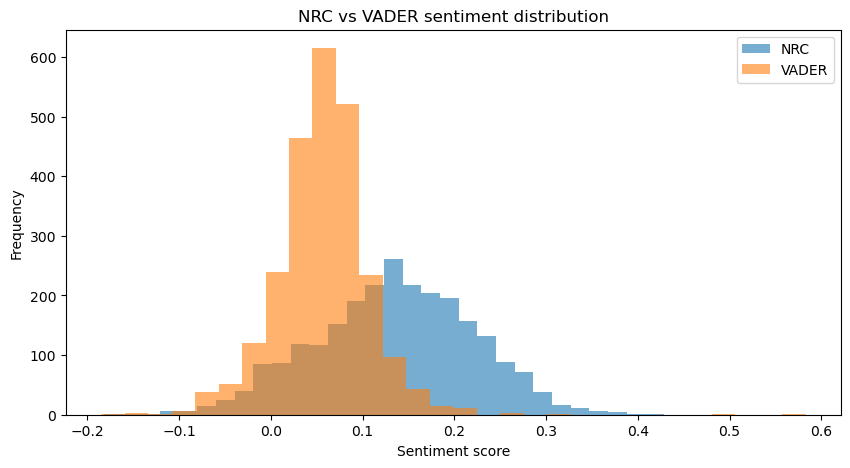

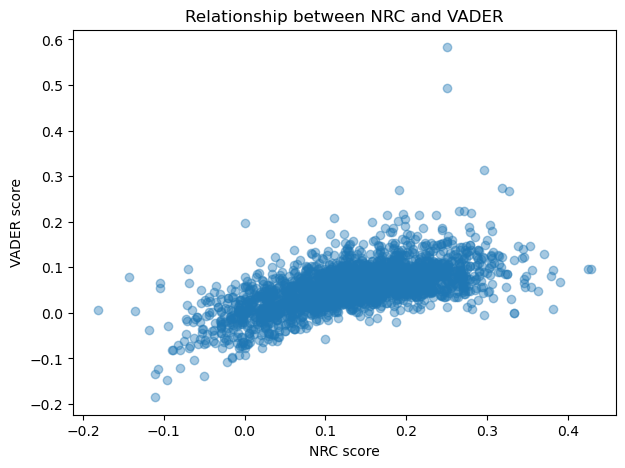

In [9]:
def get_nrc_polarity(emotions):
    positive = emotions.get("positive", 0)
    negative = emotions.get("negative", 0)
    return positive - negative

def get_vader_polarity(emotions):
    positive = emotions.get("pos", 0)
    negative = emotions.get("neg", 0)
    return positive - negative

df["nrc_score"] = df["nrc_anal"].apply(get_nrc_polarity)
df["vader_score"] = df["vader_anal"].apply(get_vader_polarity)


import matplotlib
matplotlib.use('WebAgg') # Histogram comparison
import matplotlib.pyplot as plt

%matplotlib inline
plt.figure(figsize=(10, 5))
plt.hist(df["nrc_score"], bins=30, alpha=0.6, label="NRC")
plt.hist(df["vader_score"], bins=30, alpha=0.6, label="VADER")
plt.xlabel("Sentiment score")
plt.ylabel("Frequency")
plt.title("NRC vs VADER sentiment distribution")
plt.legend()
plt.show()

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(df["nrc_score"], df["vader_score"], alpha=0.4)
plt.xlabel("NRC score")
plt.ylabel("VADER score")
plt.title("Relationship between NRC and VADER")
plt.show()


In [10]:
sia = SentimentIntensityAnalyzer()
df["vader_anal"] = df["clean_text"].apply(sia.polarity_scores)

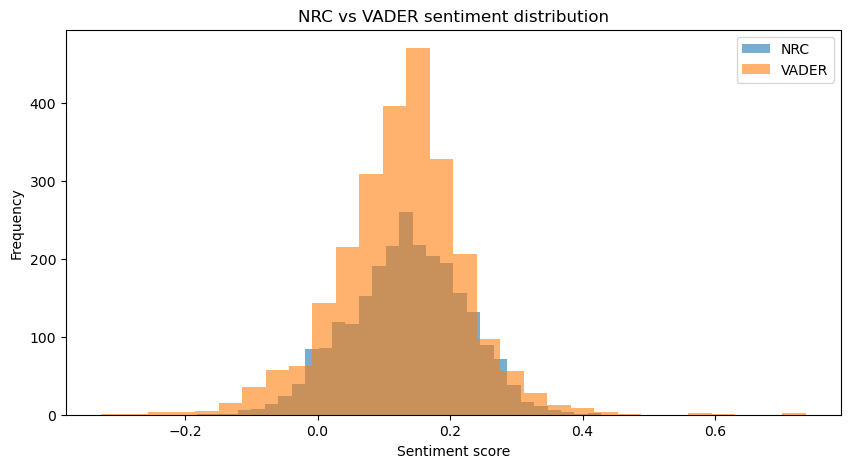

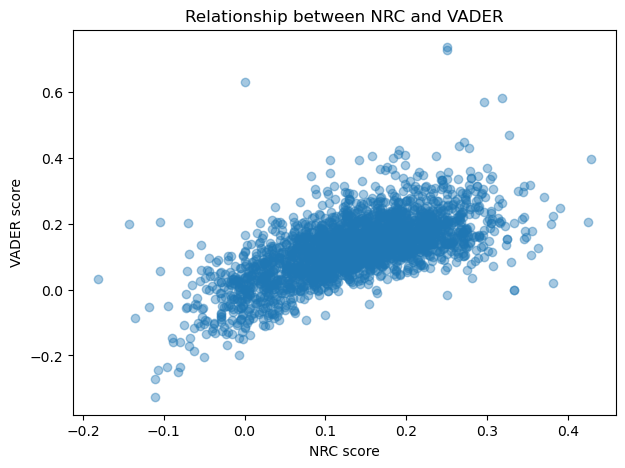

In [11]:
def get_nrc_polarity(emotions):
    positive = emotions.get("positive", 0)
    negative = emotions.get("negative", 0)
    return positive - negative

def get_vader_polarity(emotions):
    positive = emotions.get("pos", 0)
    negative = emotions.get("neg", 0)
    return positive - negative

df.drop(columns=["nrc_score","vader_score"])
df["nrc_score"] = df["nrc_anal"].apply(get_nrc_polarity)
df["vader_score"] = df["vader_anal"].apply(get_vader_polarity)


import matplotlib
matplotlib.use('WebAgg') # Histogram comparison
import matplotlib.pyplot as plt

%matplotlib inline
plt.figure(figsize=(10, 5))
plt.hist(df["nrc_score"], bins=30, alpha=0.6, label="NRC")
plt.hist(df["vader_score"], bins=30, alpha=0.6, label="VADER")
plt.xlabel("Sentiment score")
plt.ylabel("Frequency")
plt.title("NRC vs VADER sentiment distribution")
plt.legend()
plt.show()

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(df["nrc_score"], df["vader_score"], alpha=0.4)
plt.xlabel("NRC score")
plt.ylabel("VADER score")
plt.title("Relationship between NRC and VADER")
plt.show()


In [12]:
import ast
unique_list = []
df["tags"] = df["tags"].apply(ast.literal_eval).to_list()
for lst in df["tags"]:
    for item in lst:
        item=item.lower()
        if item not in unique_list:
            unique_list.append(item)
from pprint import pprint
pprint(unique_list)
pprint(len(unique_list))



['children',
 'creativity',
 'culture',
 'dance',
 'education',
 'parenting',
 'teaching',
 'alternative energy',
 'cars',
 'climate change',
 'environment',
 'global issues',
 'science',
 'sustainability',
 'technology',
 'computers',
 'entertainment',
 'interface design',
 'media',
 'music',
 'performance',
 'simplicity',
 'software',
 'macarthur grant',
 'activism',
 'business',
 'cities',
 'green',
 'inequality',
 'politics',
 'pollution',
 'africa',
 'asia',
 'google',
 'demo',
 'economics',
 'global development',
 'health',
 'math',
 'statistics',
 'visualizations',
 'goal-setting',
 'motivation',
 'potential',
 'psychology',
 'christianity',
 'god',
 'atheism',
 'comedy',
 'humor',
 'religion',
 'storytelling',
 'architecture',
 'collaboration',
 'design',
 'library',
 'ted brain trust',
 'brain',
 'cognitive science',
 'consciousness',
 'evolution',
 'philosophy',
 'happiness',
 'leadership',
 'philanthropy',
 'disaster relief',
 'invention',
 'open-source',
 'ted prize',
 'art

In [13]:
THEME_MAP = {
    "Science & Technology": [
        "science", "technology", "computers", "software", "code", "programming",
        "ai", "robots", "virtual reality", "internet", "web", "microsoft", "google",
        "online video", "hack", "demo", "interface design", "open-source", "wikipedia",
        "innovation", "invention", "engineering", "materials", "nanoscale", "chemistry",
        "string theory", "complexity", "simplicity", "rocket science", "telescopes",
        "drones", "biomechanics", "biomimicry", "animation", "gaming","physics", "data"
    ],
    "Environment & Nature": [
        "environment", "climate change", "sustainability", "green", "pollution",
        "alternative energy", "solar energy", "wind energy", "energy", "water",
        "nature", "ecology", "biodiversity", "oceans", "fish", "animals", "birds",
        "insects", "ants", "bees", "plants", "garden", "trees", "agriculture",
        "natural resources", "natural disaster", "geology", "anthropocene",
        "asteroid", "mining", "plastic", "solar system"
    ],
    "Society & Politics": [
        "politics", "policy", "democracy", "government", "law", "corruption",
        "military", "war", "terrorism", "violence", "crime", "prison", "evil",
        "inequality", "race", "gender", "women", "activism", "social change",
        "global issues", "global development", "state-building", "united states",
        "europe", "africa", "asia", "china", "india", "brazil", "south america",
        "new york", "cities", "urban planning", "infrastructure", "community",
        "world cultures", "ancient world", "history", "human origins", "humanity","culture","society"
    ],
    "Business & Economics": [
        "business", "economics", "entrepreneur", "investment", "microfinance",
        "money", "marketing", "consumerism", "shopping", "work", "leadership",
        "productivity", "work-life balance", "goal-setting", "success", "innovation",
        "women in business", "telecom", "transportation", "cars", "infrastructure"
    ],
    "Health & Medicine": [
        "health", "medicine", "disease", "cancer", "aids", "ebola", "virus",
        "bacteria", "vaccines", "health care", "public health", "heart health",
        "obesity", "aging", "genetics", "dna", "biotech", "biology", "microbiology",
        "neuroscience", "brain", "cognitive science", "prosthetics", "illness",
        "depression", "mental health", "suicide", "alzheimer's", "bioethics",
        "astrobiology", "death"
    ],
    "Arts & Culture": [
        "art", "design", "architecture", "film", "movies", "music", "performance",
        "dance", "theater", "photography", "literature", "books", "poetry",
        "writing", "storytelling", "spoken word", "comedy", "humor", "animation",
        "typography", "fashion", "beauty", "origami", "museums", "library",
        "industrial design", "product design", "science and art", "performance art",
        "live music", "singer", "violin", "piano", "guitar", "cello", "vocals",
        "composing", "conducting", "guitar", "ted brain trust","culture","society"
    ],
    "Psychology & Mind": [
        "psychology", "happiness", "motivation", "potential", "personal growth",
        "decision-making", "choice", "mind", "memory", "consciousness", "identity",
        "self", "personality", "introvert", "body language", "fear", "empathy",
        "compassion", "love", "relationships", "evolutionary psychology",
        "behavior", "morality", "curiosity", "play", "creativity"
    ],
    "Education & Learning": [
        "education", "teaching", "children", "parenting", "youth", "learning",
        "wunderkind", "presentation", "communication", "language", "math",
        "statistics", "visualizations", "macarthur grant", "ted prize", "ted fellows",
        "tedx", "interview","society"
    ],
    "Space & Exploration": [
        "space", "cosmos", "universe", "astronomy", "nasa", "moon", "mars",
        "planets", "flight", "aircraft", "exploration", "adventure", "travel",
        "dark matter", "big bang", "extraterrestrial life", "submarine","physics"
    ],
    "Religion & Philosophy": [
        "religion", "christianity", "god", "atheism", "buddhism", "faith",
        "philosophy", "evolution", "life", "time", "charter for compassion",
        "ancient world"
    ],
    "Society & Lifestyle": [
        "food", "sex", "family", "sports", "extreme sports", "social media",
        "news", "media", "entertainment", "map", "smell", "senses", "illusion",
        "magic", "meme", "toy", "materials", "narcotics", "sociology",
        "anthropology", "archaeology", "paleontology", "dinosaurs", "primates",
        "apes", "poverty", "philanthropy", "disaster relief", "peace",
        "collaboration", "human origins", "intelligence","culture","society"
    ],
}

## 6. Manual Theme Categorization

The TED dataset contains a very large and diverse collection of tags attached to each talk.
While these tags are useful, many of them are either highly specific, overlapping, or inconsistent in meaning. Because of this, the tags were manually grouped into broader thematic categories to make the dataset easier to analyze and visualize.

Categories list:

Society & Politics       
Science & Technology     
Arts & Culture           
Health & Medicine        
Environment & Nature     
Business & Economics     
Education & Learning      
Psychology & Mind         
Society & Lifestyle       
Space & Exploration       
Religion & Philosophy     

During the mapping process, each unique TED tag was reviewed and assigned to the most appropriate category. Since many TED topics naturally connect to multiple disciplines, a small amount of overlap between themes was expected and intentionally allowed where useful.

### Mapping Results

* **Total unique tags:** 298
* **Mapped tags:** 296
* **Unmapped tags:** 2
* **Tags appearing in multiple themes:** 9

Only two tags were intentionally excluded:
Unmapped tags:
['future', 'prediction']

These were left unmapped because they were considered too broad and ambiguous to represent a specific topic area reliably.

### Duplicate / Overlapping Tags

Some tags were allowed to appear in more than one category because they are naturally interdisciplinary topics. Examples include:

Duplicate mappings:
['culture', 'physics', 'innovation', 'materials', 'animation', 'human origins', 'infrastructure', 'ancient world', 'society']

For example:

* `innovation` may relate to both technology and business,
* `culture` can connect to society, history, or education,
* and `physics` may overlap with both science and engineering themes.

## 7. Theme Assignment Logic

After creating the categories, each TED Talk was assigned to a final theme based on its tags.

For every talk, all associated tags were checked against the theme mapping dictionary. Each matching tag increased the score of its corresponding theme. After all tags were counted, the talk was assigned to the theme with the highest score.


In [14]:
def assign_theme(tags: list) -> str:
    scores = {theme: 0 for theme in THEME_MAP}
    tags = [t.lower() for t in tags]
    for tag in tags:
        tag = tag.lower()
        for theme, keywords in THEME_MAP.items():
            if tag in keywords:
                scores[theme] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "Other"

df["theme"] = df["tags"].apply(assign_theme)
print(df["theme"].value_counts())

print(df[df["theme"] == "Other"])

theme
Society & Politics       614
Science & Technology     511
Arts & Culture           443
Health & Medicine        235
Environment & Nature     206
Business & Economics     133
Education & Learning      93
Psychology & Mind         88
Society & Lifestyle       74
Space & Exploration       47
Religion & Philosophy     23
Name: count, dtype: int64
Empty DataFrame
Columns: [comments, description, duration, event, film_date, languages, main_speaker, name, num_speaker, published_date, ratings, related_talks, speaker_occupation, tags, title, views, transcript, clean_tokens, clean_text, nrc_anal, vader_anal, nrc_score, vader_score, theme]
Index: []

[0 rows x 24 columns]


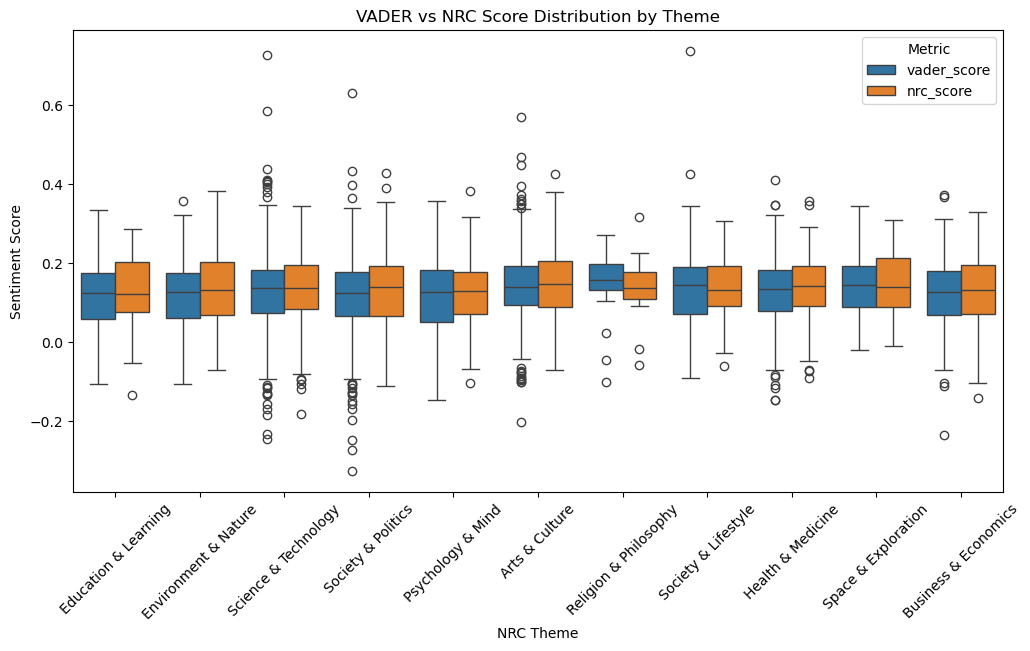

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# reshape to long format
df_long = df.melt(
    id_vars="theme",
    value_vars=["vader_score", "nrc_score"],
    var_name="sentiment_type",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.boxplot(x="theme", y="score", hue="sentiment_type", data=df_long)

plt.xticks(rotation=45)
plt.xlabel("NRC Theme")
plt.ylabel("Sentiment Score")
plt.title("VADER vs NRC Score Distribution by Theme")
plt.legend(title="Metric")
plt.show()

In [16]:
import torch

print("Torch version:", torch.__version__)
print("Torch file:", torch.__file__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0
Torch file: C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\torch\__init__.py
CUDA build: None
CUDA available: False


In [17]:
from transformers import pipeline

device = -1  # CPU
summariser = pipeline("summarization", model="pszemraj/led-base-book-summary", device=device)
sentiment = pipeline("sentiment-analysis", device=device)
def transform_to_num(doc):
    compressed_talk = summariser(doc,  max_length=500)[0]["summary_text"]
    data = sentiment(compressed_talk,batch_size=64,max_length=512)
    pprint(data)
    if data[0].get("label") == "NEGATIVE": 
        return data[0]["score"]*-1
    return data[0]["score"]
    
df["ml_anal"] = df["transcript"].apply(transform_to_num)


C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbe

[{'label': 'POSITIVE', 'score': 0.9846735000610352}]
[{'label': 'POSITIVE', 'score': 0.9805150032043457}]
[{'label': 'NEGATIVE', 'score': 0.9987971782684326}]
[{'label': 'NEGATIVE', 'score': 0.9788076877593994}]
[{'label': 'NEGATIVE', 'score': 0.9902897477149963}]
[{'label': 'POSITIVE', 'score': 0.9214068651199341}]
[{'label': 'NEGATIVE', 'score': 0.8277040123939514}]
[{'label': 'POSITIVE', 'score': 0.5830817222595215}]
[{'label': 'POSITIVE', 'score': 0.9994342923164368}]
[{'label': 'NEGATIVE', 'score': 0.9888015985488892}]
[{'label': 'POSITIVE', 'score': 0.948525607585907}]
[{'label': 'POSITIVE', 'score': 0.9683517813682556}]
[{'label': 'POSITIVE', 'score': 0.6548284888267517}]
[{'label': 'POSITIVE', 'score': 0.9879260063171387}]
[{'label': 'POSITIVE', 'score': 0.9778613448143005}]
[{'label': 'NEGATIVE', 'score': 0.9914817810058594}]
[{'label': 'POSITIVE', 'score': 0.957578718662262}]
[{'label': 'NEGATIVE', 'score': 0.6664925217628479}]
[{'label': 'POSITIVE', 'score': 0.99802690744400

Your max_length is set to 500, but your input_length is only 281. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=140)


[{'label': 'POSITIVE', 'score': 0.9964454770088196}]
[{'label': 'POSITIVE', 'score': 0.9995457530021667}]
[{'label': 'NEGATIVE', 'score': 0.8471960425376892}]
[{'label': 'NEGATIVE', 'score': 0.9470838904380798}]
[{'label': 'POSITIVE', 'score': 0.9978711605072021}]
[{'label': 'POSITIVE', 'score': 0.9989412426948547}]
[{'label': 'NEGATIVE', 'score': 0.9975071549415588}]
[{'label': 'POSITIVE', 'score': 0.9819775223731995}]


Your max_length is set to 500, but your input_length is only 497. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=248)


...

[{'label': 'POSITIVE', 'score': 0.9966179728507996}]
[{'label': 'POSITIVE', 'score': 0.9977328777313232}]
[{'label': 'POSITIVE', 'score': 0.8902600407600403}]
[{'label': 'POSITIVE', 'score': 0.7010199427604675}]
[{'label': 'POSITIVE', 'score': 0.5529942512512207}]
[{'label': 'POSITIVE', 'score': 0.9972512125968933}]
[{'label': 'NEGATIVE', 'score': 0.9794506430625916}]
[{'label': 'NEGATIVE', 'score': 0.9903048276901245}]
[{'label': 'POSITIVE', 'score': 0.9708494544029236}]
[{'label': 'POSITIVE', 'score': 0.9872235059738159}]
[{'label': 'NEGATIVE', 'score': 0.9790584444999695}]
[{'label': 'NEGATIVE', 'score': 0.9956888556480408}]
[{'label': 'POSITIVE', 'score': 0.9946551322937012}]
[{'label': 'NEGATIVE', 'score': 0.9944546818733215}]
[{'label': 'NEGATIVE', 'score': 0.9913602471351624}]
[{'label': 'NEGATIVE', 'score': 0.9973620772361755}]
[{'label': 'POSITIVE', 'score': 0.9874666333198547}]
[{'label': 'NEGATIVE', 'score': 0.9937412142753601}]
[{'label': 'POSITIVE', 'score': 0.996000230312

Your max_length is set to 500, but your input_length is only 442. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=221)


[{'label': 'POSITIVE', 'score': 0.8549498319625854}]
[{'label': 'POSITIVE', 'score': 0.996105968952179}]
[{'label': 'POSITIVE', 'score': 0.9966566562652588}]
[{'label': 'POSITIVE', 'score': 0.9967660903930664}]
[{'label': 'POSITIVE', 'score': 0.9925143122673035}]
[{'label': 'NEGATIVE', 'score': 0.9714925289154053}]
[{'label': 'POSITIVE', 'score': 0.7530291080474854}]
[{'label': 'NEGATIVE', 'score': 0.9463226199150085}]
[{'label': 'POSITIVE', 'score': 0.9804189801216125}]
[{'label': 'NEGATIVE', 'score': 0.8696576356887817}]
[{'label': 'NEGATIVE', 'score': 0.9954903721809387}]
[{'label': 'POSITIVE', 'score': 0.9977688789367676}]
[{'label': 'NEGATIVE', 'score': 0.9926072359085083}]
[{'label': 'NEGATIVE', 'score': 0.6262621879577637}]
[{'label': 'POSITIVE', 'score': 0.9926950931549072}]
[{'label': 'NEGATIVE', 'score': 0.9893895983695984}]
[{'label': 'NEGATIVE', 'score': 0.7783998847007751}]
[{'label': 'NEGATIVE', 'score': 0.9091638922691345}]
[{'label': 'NEGATIVE', 'score': 0.9647099971771

Your max_length is set to 500, but your input_length is only 464. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=232)


[{'label': 'POSITIVE', 'score': 0.9989538192749023}]
[{'label': 'POSITIVE', 'score': 0.999467670917511}]
[{'label': 'NEGATIVE', 'score': 0.9616346955299377}]
[{'label': 'POSITIVE', 'score': 0.9921457171440125}]
[{'label': 'NEGATIVE', 'score': 0.9982604384422302}]
[{'label': 'NEGATIVE', 'score': 0.8195792436599731}]
[{'label': 'NEGATIVE', 'score': 0.9980630278587341}]
[{'label': 'POSITIVE', 'score': 0.9964088797569275}]
[{'label': 'POSITIVE', 'score': 0.992486834526062}]
[{'label': 'POSITIVE', 'score': 0.9914543628692627}]
[{'label': 'POSITIVE', 'score': 0.9989461302757263}]
[{'label': 'NEGATIVE', 'score': 0.9989392161369324}]
[{'label': 'NEGATIVE', 'score': 0.9883284568786621}]
[{'label': 'POSITIVE', 'score': 0.9966616630554199}]
[{'label': 'NEGATIVE', 'score': 0.9764881134033203}]
[{'label': 'NEGATIVE', 'score': 0.9965460896492004}]
[{'label': 'POSITIVE', 'score': 0.9988388419151306}]
[{'label': 'POSITIVE', 'score': 0.5906844735145569}]
[{'label': 'POSITIVE', 'score': 0.97524976730346

In [22]:
summariser = pipeline("summarization", model="pszemraj/led-base-book-summary", device=device)

pprint(summariser(f"summarize: {df.iloc[0]["transcript"]}", max_length=500)[0]["summary_text"])
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
pprint(summariser(f"summarize: {df.iloc[0]["transcript"]}", max_length=500)[0]["summary_text"])
summarizer = pipeline("summarization", model="google/pegasus-large")
pprint(summariser(f"summarize: {df.iloc[0]["transcript"]}", max_length=500)[0]["summary_text"])
pprint(df.iloc[0]["transcript"])

("summarize: Good morning. How are you?(Laughter) It's been great, hasn't it? "
 'I\'ve been blown away by the whole thing. In fact, I\'m leaving." The '
 "conference is packed with talk about education and creativity. There's a lot "
 'of overlap between the two topics. Education is meant to take us into the '
 "future that we can't grasp. Brain science has always been based on the idea "
 'of "artificial intelligence," which means that kids don\'t learn anything '
 "until they're adults. Brain scientists agree that education should be "
 "treated with the same status as literacy because it's going to help them "
 'reach their goals in the future. They also agree that our education system '
 'needs to rethink its view of intelligence. For example, if your son was four '
 'years old when he was in the Nativity play, he would have been in his '
 "Nativity theater at least one year. But now he's in his mid-thirties. So "
 "what does this all mean? Brain science doesn't just focus on maki

C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\elzes\.cache\huggingface\hub\models--google--pegasus-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at go

ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece installed to convert a slow tokenizer to a fast one.

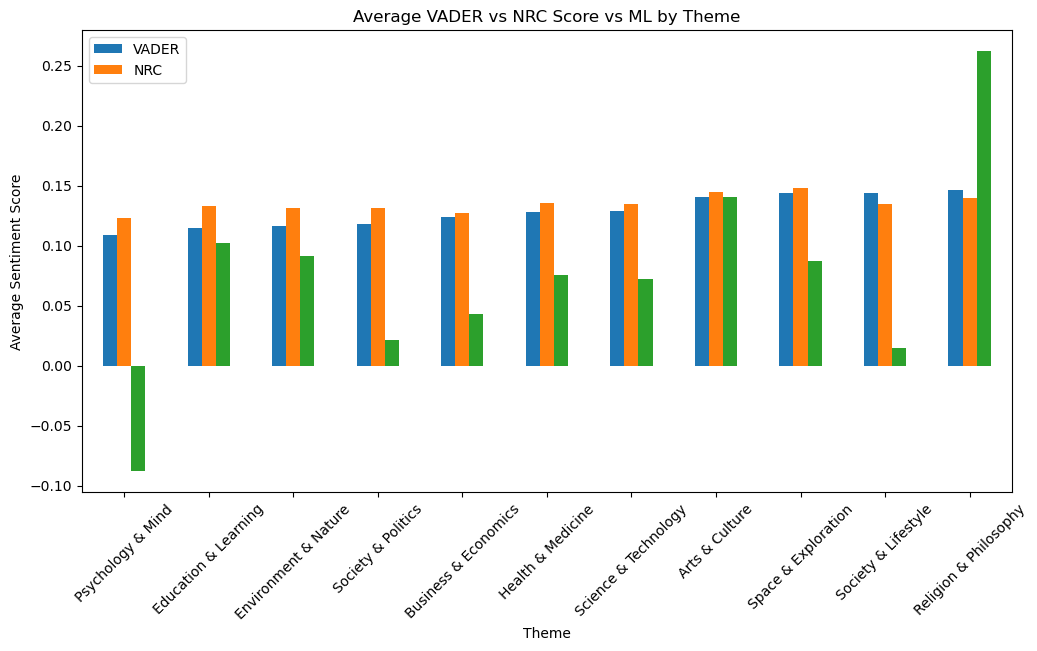

In [19]:
theme_means = df.groupby("theme")[["vader_score", "nrc_score", "ml_anal"]].mean().sort_values("vader_score")

theme_means.plot(kind="bar", figsize=(12, 6))

plt.xlabel("Theme")
plt.ylabel("Average Sentiment Score")
plt.title("Average VADER vs NRC Score vs ML by Theme")
plt.xticks(rotation=45)
plt.legend(["VADER", "NRC"])
plt.show()